<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/Main_Experiment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load the NSL_KDD dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/datasets/nsl_kdd"

!ls

drive  sample_data


In [5]:
import pandas as pd

train_path = base_path + "/KDDTrain+.txt"
test_path = base_path + "/KDDTest+.txt"

#About the dataset
Data on network connections/sessions.

Problem: Classification identify malicious

Categorical Features:protocol_type, service, flag



```
0@relation 'KDDTest'
1@attribute 'duration' real
2@attribute 'protocol_type' {'tcp','udp', 'icmp'}
3@attribute 'service' {'aol', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'harvest', 'hostnames', 'http', 'http_2784', 'http_443', 'http_8001', 'imap4', 'IRC', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois', 'X11', 'Z39_50'}
4@attribute 'flag' { 'OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH' }
5@attribute 'src_bytes' real
6@attribute 'dst_bytes' real
7@attribute 'land' {'0', '1'}
8@attribute 'wrong_fragment' real
9@attribute 'urgent' real
10@attribute 'hot' real
11@attribute 'num_failed_logins' real
12@attribute 'logged_in' {'0', '1'}
13@attribute 'num_compromised' real
14@attribute 'root_shell' real
15@attribute 'su_attempted' real
16@attribute 'num_root' real
17@attribute 'num_file_creations' real
18@attribute 'num_shells' real
19@attribute 'num_access_files' real
20@attribute 'num_outbound_cmds' real
21@attribute 'is_host_login' {'0', '1'}
22@attribute 'is_guest_login' {'0', '1'}
23@attribute 'count' real
24@attribute 'srv_count' real
25@attribute 'serror_rate' real
26@attribute 'srv_serror_rate' real
27@attribute 'rerror_rate' real
28@attribute 'srv_rerror_rate' real
29@attribute 'same_srv_rate' real
30@attribute 'diff_srv_rate' real
31@attribute 'srv_diff_host_rate' real
32@attribute 'dst_host_count' real
33@attribute 'dst_host_srv_count' real
34@attribute 'dst_host_same_srv_rate' real
35@attribute 'dst_host_diff_srv_rate' real
36@attribute 'dst_host_same_src_port_rate' real
37@attribute 'dst_host_srv_diff_host_rate' real
38@attribute 'dst_host_serror_rate' real
39@attribute 'dst_host_srv_serror_rate' real
40@attribute 'dst_host_rerror_rate' real
41@attribute 'dst_host_srv_rerror_rate' real
42@attribute 'class' {'normal', 'anomaly'}
```
Target: class - Normal or Anomaly


In [7]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "class", "difficulty"
]



df = pd.read_csv(train_path, names=columns)

print(df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [5]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum)

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [8]:
def preprocess(df):
  #drop label column
  df = df.iloc[:, :-1]

  #one-hot encoding
  df_encoded = pd.get_dummies(df, columns=["protocol_type", "service", "flag"])

  return df_encoded

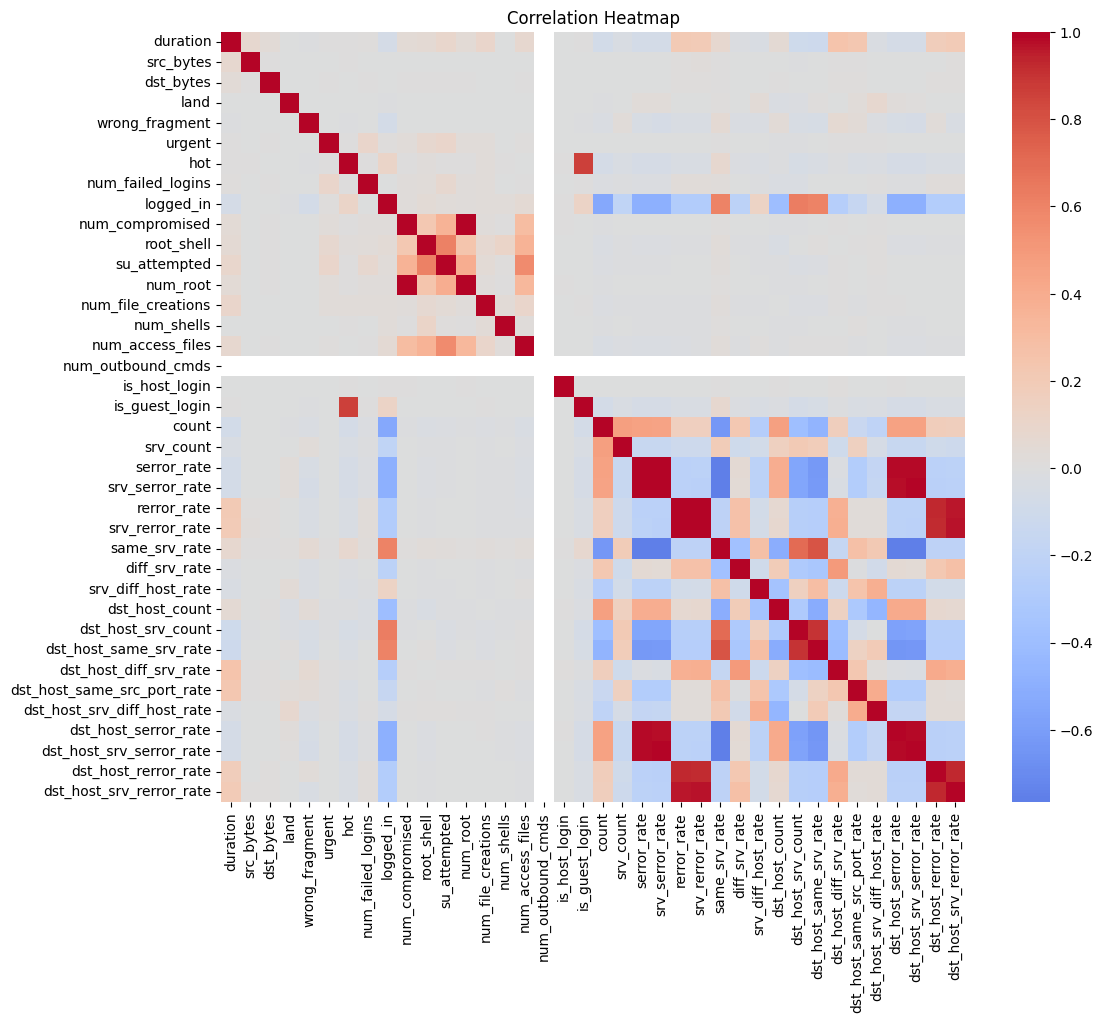

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = preprocess(df)

corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

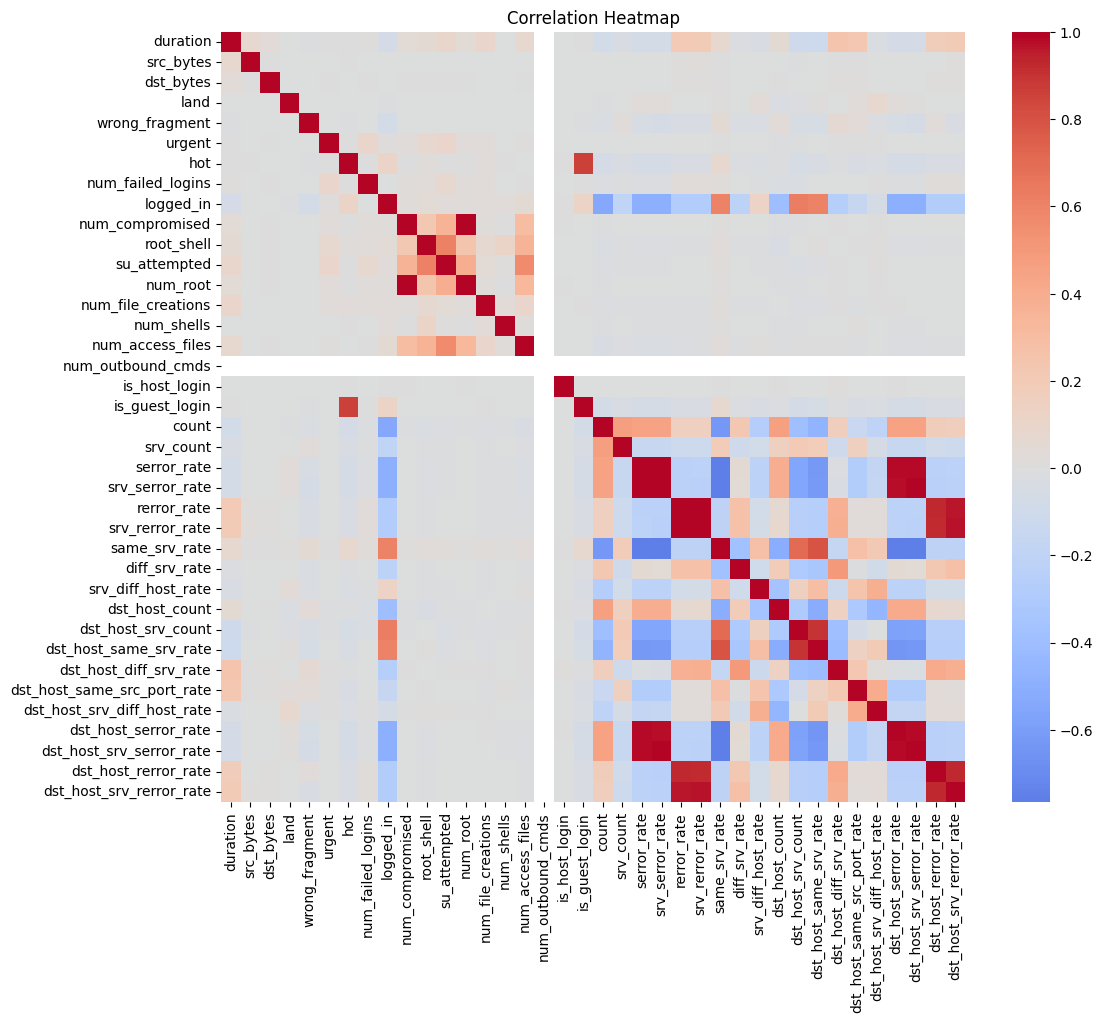

In [9]:
print(df.columns)

#Drop Highly Correlated Columns
df = df.drop(columns=["dst_host_srv_rerror_rate", "dst_host_rerror_rate", "dst_host_srv_serror_rate", "dst_host_srv_serror_rate", "hot", "num_root", "dst_host_serror_rate", "srv_rerror_rate", "dst_host_same_srv_rate", "srv_serror_rate"])

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty'],
      dtype='object')


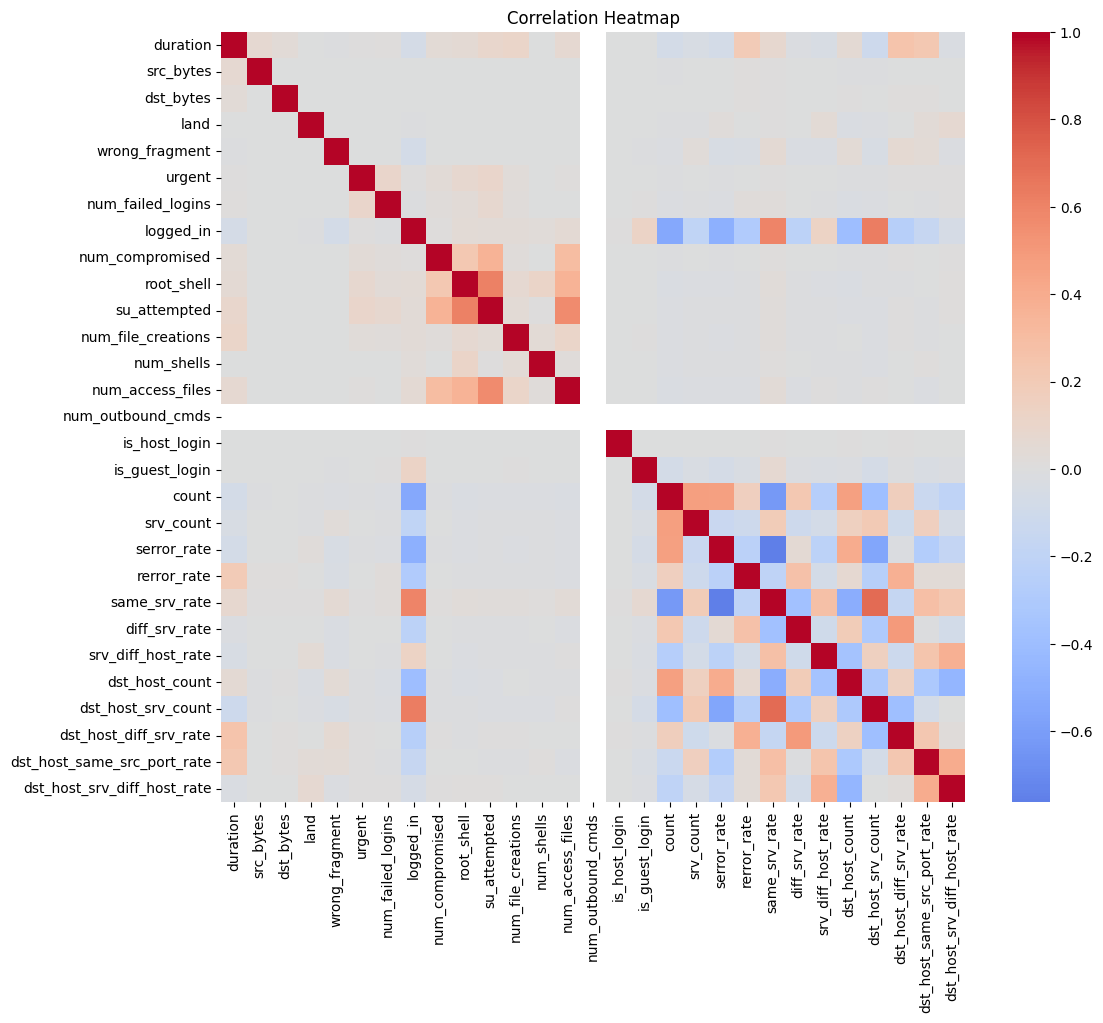

In [ ]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

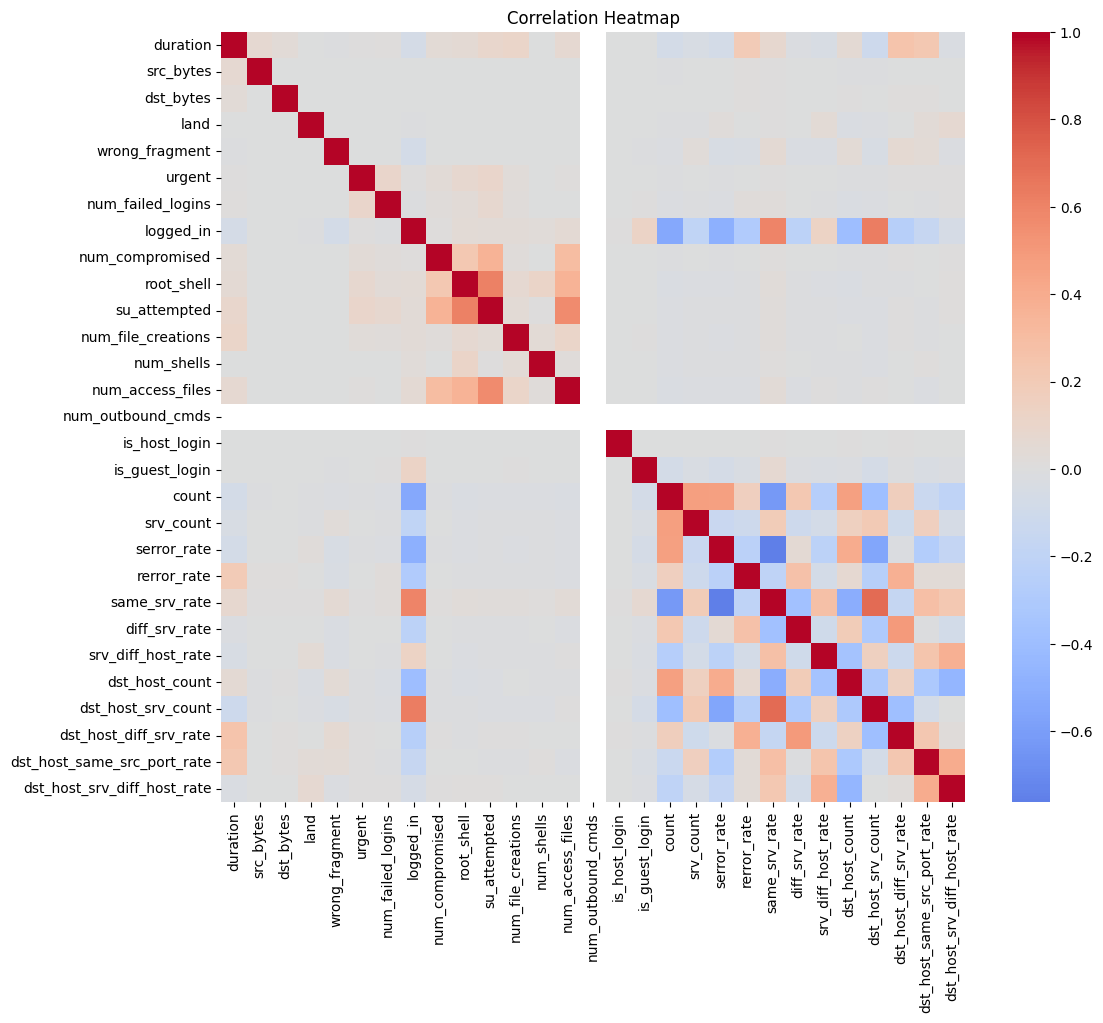

#Train Using Real for Baseline

In [69]:
df_test.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
1,0,0,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
2,2,12983,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,20,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,1,0,15,0,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False


In [10]:
from sklearn.ensemble import RandomForestClassifier

X_train = df.drop(columns=["class"])
y_train = df["class"]

df_test = pd.read_csv(test_path, names=columns)
df_test = preprocess(df_test)
X_test = df_test.drop(columns=["class"])
y_test = df_test["class"]

X = pd.concat([X_train, X_test], axis=0)
X = pd.get_dummies(X)
X_train = X.iloc[:X_train.shape[0]]
X_test = X.iloc[X_train.shape[0]:]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=7
)

In [71]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns)

(125973, 279)
(22544, 279)
Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell',
       ...
       'flag_S1_False', 'flag_S1_True', 'flag_S2_False', 'flag_S2_True',
       'flag_S3_False', 'flag_S3_True', 'flag_SF_False', 'flag_SF_True',
       'flag_SH_False', 'flag_SH_True'],
      dtype='object', length=279)


In [72]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=7)

In [73]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.669402058197303

Accuracy: 0.669402058197303

#Gaussian Copula Synthesizer

In [ ]:
!pip install sdv

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

data = df.copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

gcs = GaussianCopulaSynthesizer(metadata)
gcs.fit(data)

samples = gcs.sample(num_rows=1000)

samples.to_csv(base_path+"/gsc_network_samples.csv")

for i in range(10):
  samples = gcs.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/gsc_network_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/gsc_network_samples_large.csv", mode="a", header=False, index=False)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [48]:
synthetic_df = pd.read_csv(base_path+"/gsc_network_samples_large.csv")

In [49]:
synthetic_df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,num_failed_logins,logged_in,num_compromised,root_shell,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,12201,18782,0,0,0,0,1,236,0,...,False,False,False,False,False,False,False,False,True,False
1,75,111893,357543,0,0,0,0,0,638,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,102,0,...,False,False,False,False,True,False,False,False,False,False
3,7,273,8570,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,20,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [38]:
df = preprocess(df)

In [39]:
# Decode
service_cols = [c for c in df.columns if c.startswith("service_")]
flag_cols = [c for c in df.columns if c.startswith("flag_")]
protocol_cols = [c for c in df.columns if c.startswith("protocol_type_")]

df["service"] = df[service_cols].idxmax(axis=1).str.replace("service_", "")
df["flag"] = df[flag_cols].idxmax(axis=1).str.replace("flag_", "")
df["protocol_type"] = df[protocol_cols].idxmax(axis=1).str.replace("protocol_type_", "")

# Drop the one-hot columns
df = df.drop(columns=service_cols + flag_cols + protocol_cols)

In [40]:
# Decode
service_cols = [c for c in synthetic_df.columns if c.startswith("service_")]
flag_cols = [c for c in synthetic_df.columns if c.startswith("flag_")]
protocol_cols = [c for c in synthetic_df.columns if c.startswith("protocol_type_")]

synthetic_df["service"] = synthetic_df[service_cols].idxmax(axis=1).str.replace("service_", "")
synthetic_df["flag"] = synthetic_df[flag_cols].idxmax(axis=1).str.replace("flag_", "")
synthetic_df["protocol_type"] = synthetic_df[protocol_cols].idxmax(axis=1).str.replace("protocol_type_", "")

# Drop the one-hot columns
synthetic_df = synthetic_df.drop(columns=service_cols + flag_cols + protocol_cols)

In [41]:
print(df["protocol_type"])
print(synthetic_df["protocol_type"])

0         tcp
1         udp
2         tcp
3         tcp
4         tcp
         ... 
125968    tcp
125969    udp
125970    tcp
125971    tcp
125972    tcp
Name: protocol_type, Length: 125973, dtype: object
0        tcp
1        tcp
2        tcp
3        udp
4        tcp
        ... 
9995     tcp
9996    icmp
9997    icmp
9998    icmp
9999     tcp
Name: protocol_type, Length: 10000, dtype: object


In [50]:
os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [20]:
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# INPUTS
def do_inputs():
  global target
  target = "class"

  global numeric_cols
  numeric_cols = real_df.select_dtypes(include=['number']).columns

  global categorical_cols
  categorical_cols = ["protocol_type","service","flag"]


# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()
        plt.savefig(f"{base_path}/10K_Samples/KDE_Comparison_{col}.png")

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()
        plt.savefig(f"{base_path}/10K_Samples/Categorical_Distribution_{col}.png")

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()
    plt.savefig(f"{base_path}/10K_Samples/Correlation_Comparison.png")

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    # One-hot encode
    real_enc = pd.get_dummies(real, columns=["protocol_type", "service", "flag"])
    syn_enc = pd.get_dummies(syn, columns=["protocol_type", "service", "flag"])

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)

    X_real = real_enc.drop(columns=[target])
    y_real = real_enc[target]

    X_syn = syn_enc.drop(columns=[target])
    y_syn = syn_enc[target]

    model = RandomForestClassifier(n_estimators=100, random_state=7)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    print(accuracy_score(y_real, preds))


In [53]:
do_inputs()

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)

ML utility test...


KeyError: "None of [Index(['protocol_type', 'service', 'flag'], dtype='object')] are in the [columns]"



```
Running KS test...
                         column   ks_stat        p_value
0                      duration  0.487575   0.000000e+00
1                     src_bytes  0.288740   0.000000e+00
2                     dst_bytes  0.210915   0.000000e+00
3                          land  0.028402   6.314188e-07
4                wrong_fragment  0.054947   9.382685e-25
5                        urgent  0.027729   1.272344e-06
6             num_failed_logins  0.000968   1.000000e+00
7                     logged_in  0.048336   2.993259e-19
8               num_compromised  0.027291   1.987579e-06
9                    root_shell  0.001342   1.000000e+00
10                 su_attempted  0.000635   1.000000e+00
11           num_file_creations  0.002278   1.000000e+00
12                   num_shells  0.000373   1.000000e+00
13             num_access_files  0.002945   9.999977e-01
14            num_outbound_cmds  0.000000   1.000000e+00
15                is_host_login  0.006092   8.796233e-01
16               is_guest_login  0.043277   1.622651e-15
17                        count  0.104451   1.825666e-88
18                    srv_count  0.101514   1.419205e-83
19                  serror_rate  0.348967   0.000000e+00
20                  rerror_rate  0.526980   0.000000e+00
21                same_srv_rate  0.346500   0.000000e+00
22                diff_srv_rate  0.351326   0.000000e+00
23           srv_diff_host_rate  0.527063   0.000000e+00
24               dst_host_count  0.056127   8.247780e-26
25           dst_host_srv_count  0.150020  1.692029e-182
26       dst_host_diff_srv_rate  0.162409  5.399232e-214
27  dst_host_same_src_port_rate  0.179390  2.495207e-261
28  dst_host_srv_diff_host_rate  0.218362   0.000000e+00
Categorical comparison...
<Figure size 640x480 with 0 Axes>
```



```
ML utility test...
0.9677391187000389
<Figure size 640x480 with 0 Axes>
```





In [ ]:
for col in synthetic_df.columns:
  print(col)

duration
src_bytes
dst_bytes
land
wrong_fragment
urgent
num_failed_logins
logged_in
num_compromised
root_shell
su_attempted
num_file_creations
num_shells
num_access_files
num_outbound_cmds
is_host_login
is_guest_login
count
srv_count
serror_rate
rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate
dst_host_count
dst_host_srv_count
dst_host_diff_srv_rate
dst_host_same_src_port_rate
dst_host_srv_diff_host_rate
class
service
flag
protocol_type


#CTGAN

In [12]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.6 MB/s eta 0:00:00


In [74]:
from ctgan import CTGAN
import time
import pandas as pd

In [15]:
# Load
df = pd.read_csv(train_path, names=columns)

print(df.columns)

#Drop Highly Correlated Columns
df = df.drop(columns=["dst_host_srv_rerror_rate", "dst_host_rerror_rate", "dst_host_srv_serror_rate", "dst_host_srv_serror_rate", "hot", "num_root", "dst_host_serror_rate", "srv_rerror_rate", "dst_host_same_srv_rate", "srv_serror_rate"], errors="ignore")

# Drop difficulty if present
df = df.drop(columns=["difficulty"], errors="ignore")

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty'],
      dtype='object')


In [75]:
discrete_columns = [
    "protocol_type", "service", "flag",
    "land", "wrong_fragment", "urgent",
    "logged_in", "is_host_login", "is_guest_login",
    "class"
]

In [22]:
from ctgan import CTGAN
ctgan = CTGAN(enable_gpu=True)

start_time = time.time()
print(f"Started fitting [{start_time}]...")
ctgan.fit(df, discrete_columns = discrete_columns)

end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {end_time- start_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = ctgan.sample(1000)
end_time = time.time()
samples.to_csv(base_path+"/ctgan_network_samples.csv", index=False)

print(f"1000 Samples in {end_time - start_time}.")

start_time = time.time()
print(f"Starting large batch of samples [{start_time}].")

for i in range(10):
  samples = ctgan.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/ctgan_network_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/ctgan_network_samples_large.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"10000 Samples in {end_time - start_time}. Finished [{end_time}].")

for i in range(100):
  samples = ctgan.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/ctgan_network_samples_Xlarge.csv", index=False)
  else:
    samples.to_csv(base_path+"/ctgan_network_samples_Xlarge.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"100000 Samples in {end_time - start_time}. Finished [{end_time}].")

Started fitting [1776793031.653634]...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Finished fitting [1776797290.95879]. Total run time: 4259.305155992508.
Generating Samples [1776797290.9590602]...
1000 Samples in -0.1402738094329834.
Starting large batch of samples [1776797291.1361554].
10000 Samples in 2.1955087184906006. Finished [1776797293.331664].
100000 Samples in 20.30331015586853. Finished [1776797311.4394655].




```
Started fitting [1776750062.5294523]...
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Finished fitting [1776754955.8234549]. Total run time: 4893.294002532959.
Generating Samples [1776754955.8237233]...
1000 Samples in -0.16949987411499023.
Starting large batch of samples [1776754956.0533683].
10000 Samples in 1.9422950744628906. Finished [1776754957.9956634].
10000 Samples in 22.853819131851196. Finished [1776754978.9071875].
```



# Analyze the Artifical Dataset


In [44]:
import pandas as pd
import os

synthetic_df = pd.read_csv(base_path+"/ctgan_network_samples_large.csv")

os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [45]:
#syn_df = syn_df.drop(columns=["difficulty", "root_shell", "num_root", "num_shells", "num_outbound_cmds"], errors="ignore")
#real_df = real_df.drop(columns=["difficulty", "root_shell", "num_root", "num_shells", "num_outbound_cmds"], errors="ignore")
do_inputs()
syn_df[numeric_cols] = syn_df[numeric_cols].clip(lower=0)

In [46]:
print (real_df.columns)
print (syn_df.columns)

print(real_df["src_bytes"])
print(syn_df["src_bytes"])

print(real_df["num_outbound_cmds"])
print(syn_df["num_outbound_cmds"])

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'service',
       'flag', 'protocol_type'],
      dtype='object')
Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'num_failed_logins',
       'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'ser

Running KDE plots...


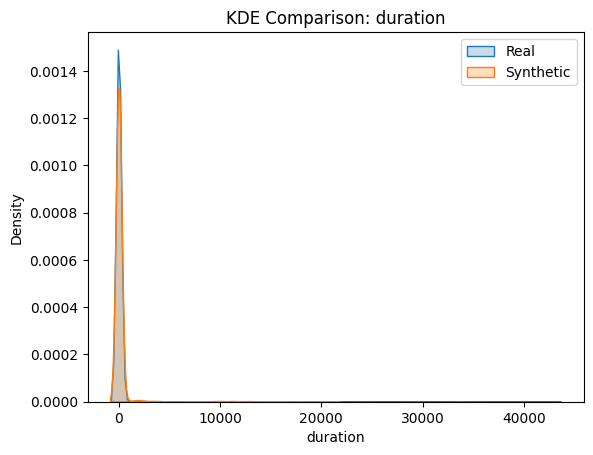

<Figure size 640x480 with 0 Axes>

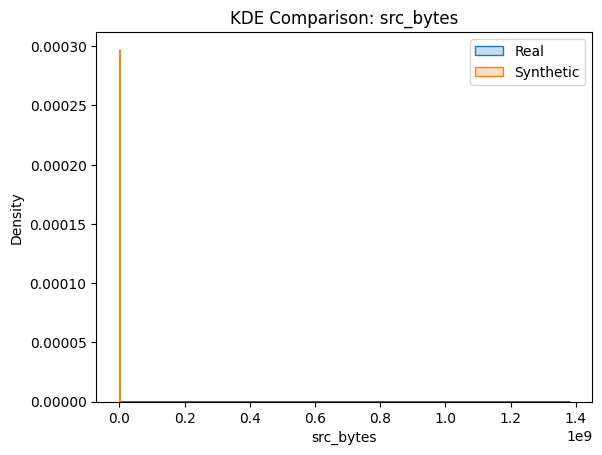

<Figure size 640x480 with 0 Axes>

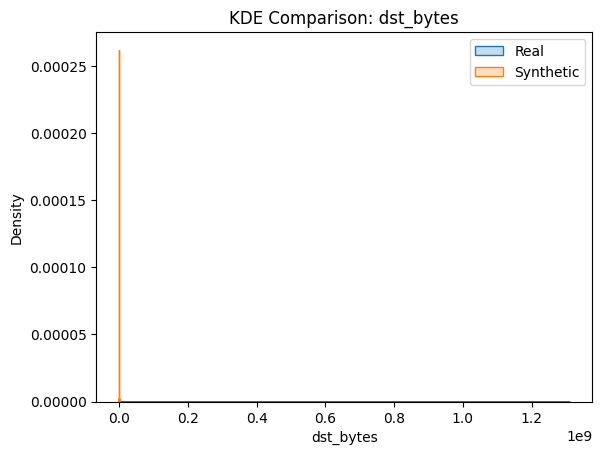

<Figure size 640x480 with 0 Axes>

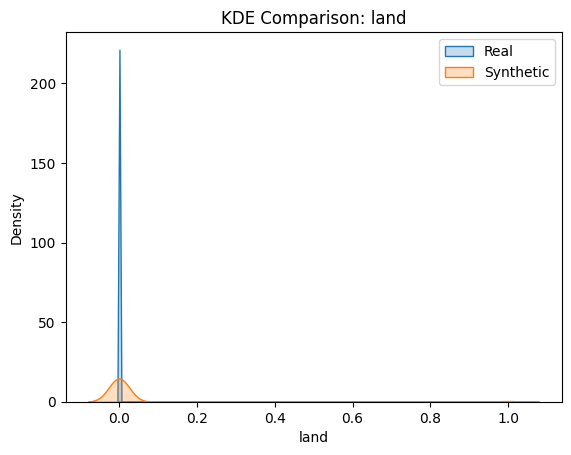

<Figure size 640x480 with 0 Axes>

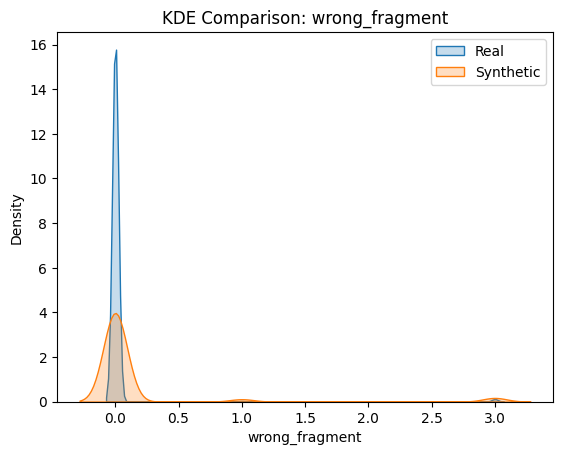

<Figure size 640x480 with 0 Axes>

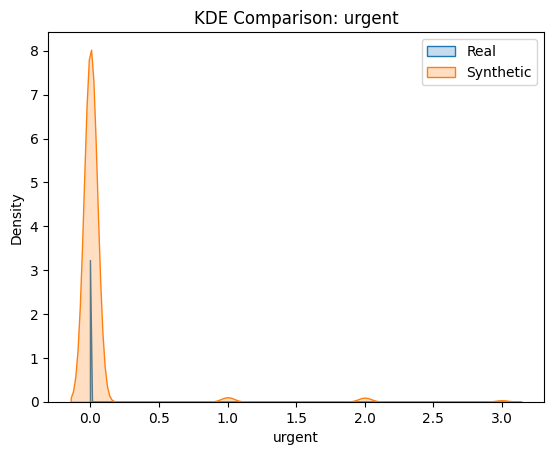

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

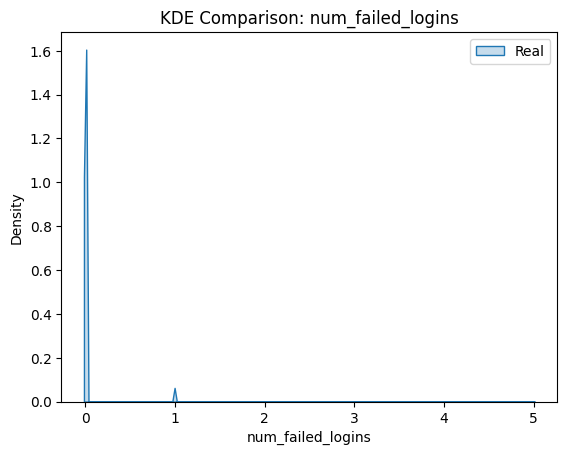

<Figure size 640x480 with 0 Axes>

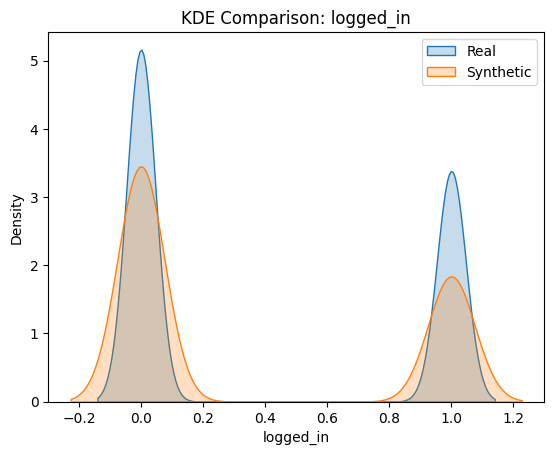

<Figure size 640x480 with 0 Axes>

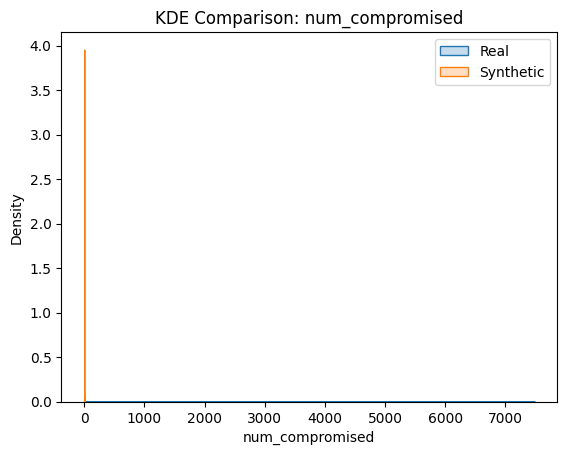

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

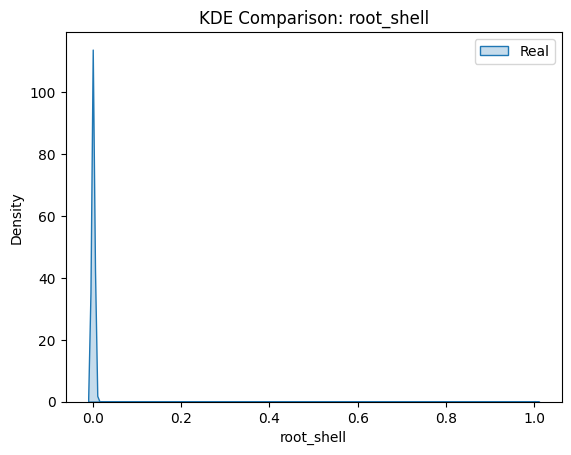

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

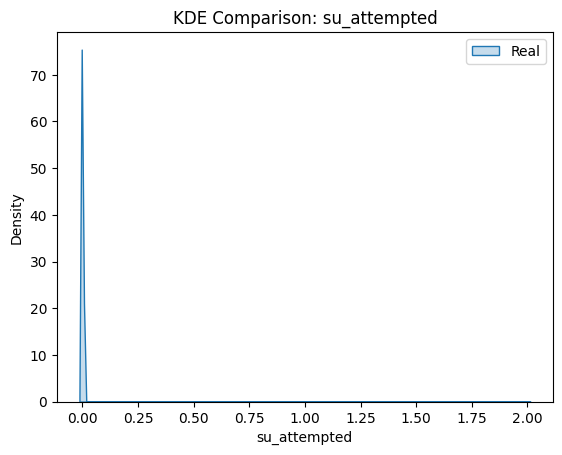

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

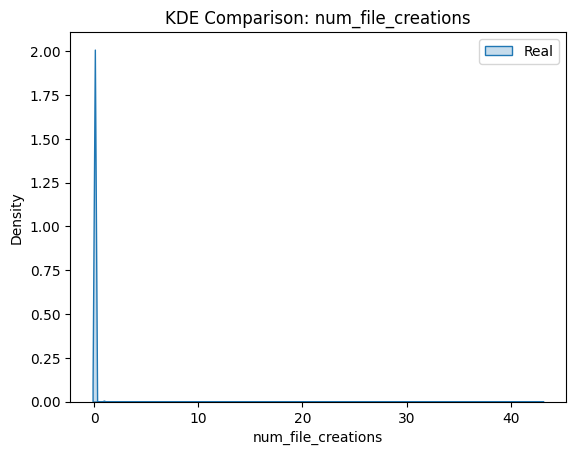

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

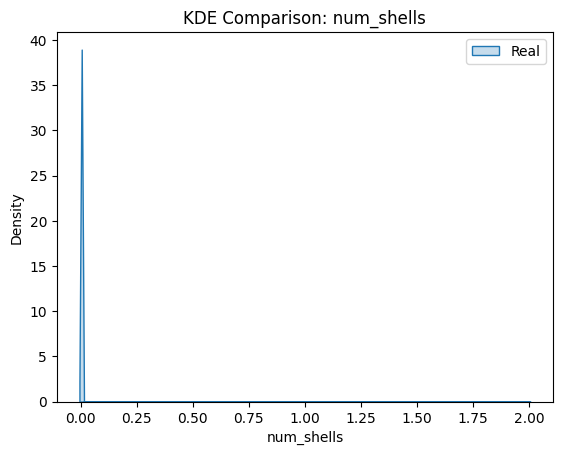

/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

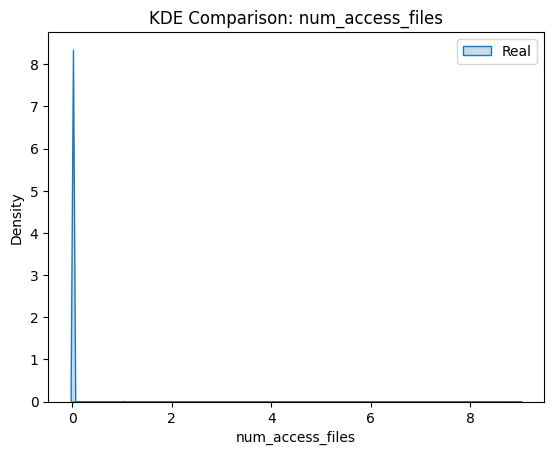

/tmp/ipykernel_1543/1199787676.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(real[col], label="Real", fill=True)
/tmp/ipykernel_1543/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)
/tmp/ipykernel_1543/1199787676.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

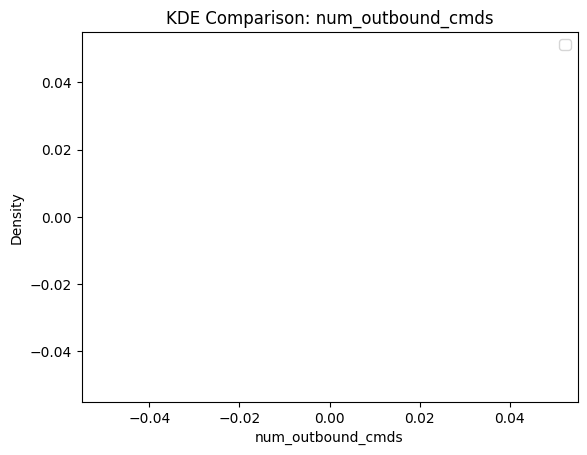

<Figure size 640x480 with 0 Axes>

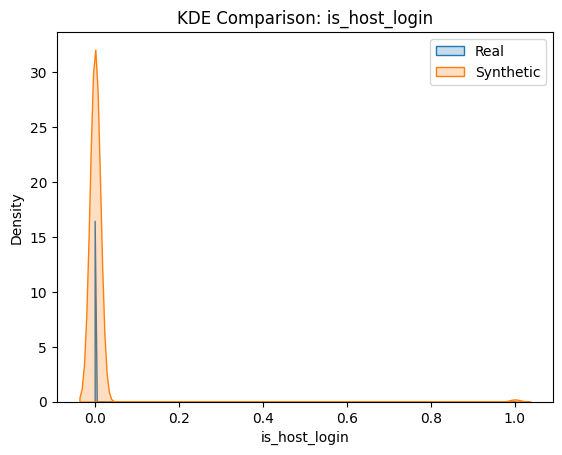

<Figure size 640x480 with 0 Axes>

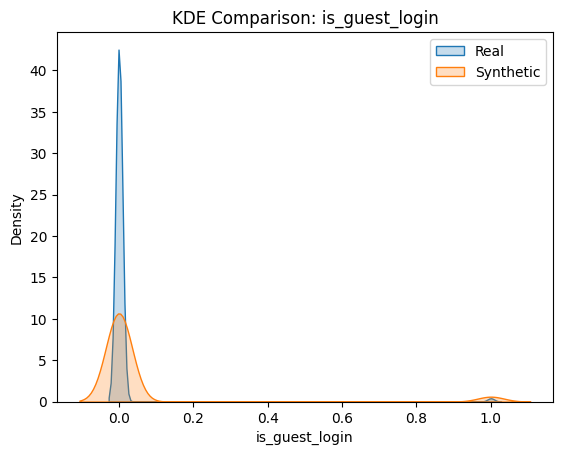

<Figure size 640x480 with 0 Axes>

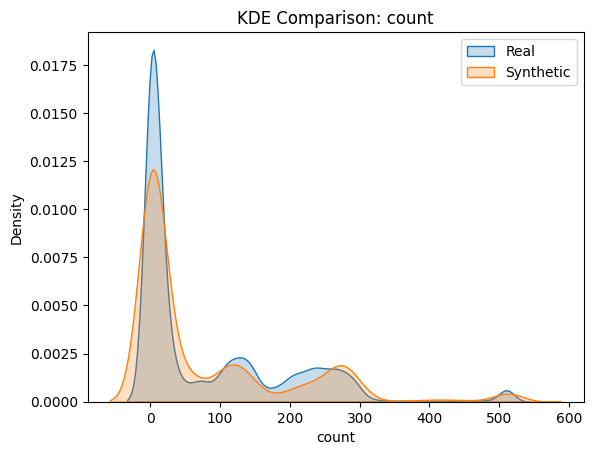

<Figure size 640x480 with 0 Axes>

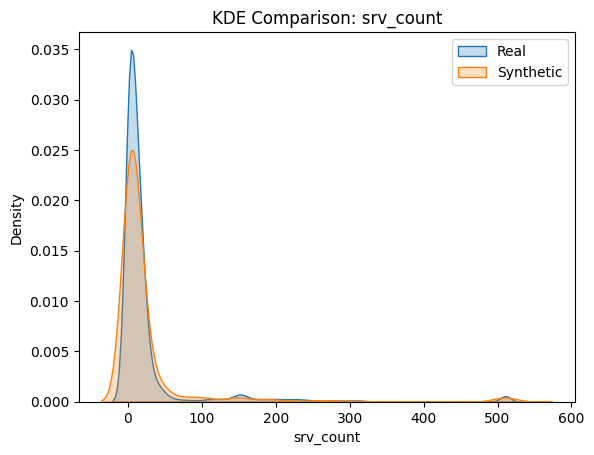

<Figure size 640x480 with 0 Axes>

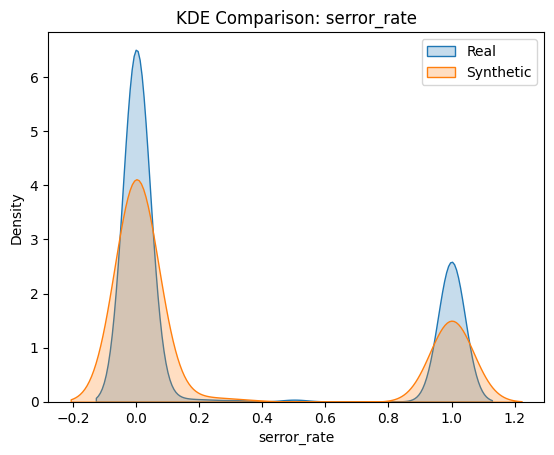

<Figure size 640x480 with 0 Axes>

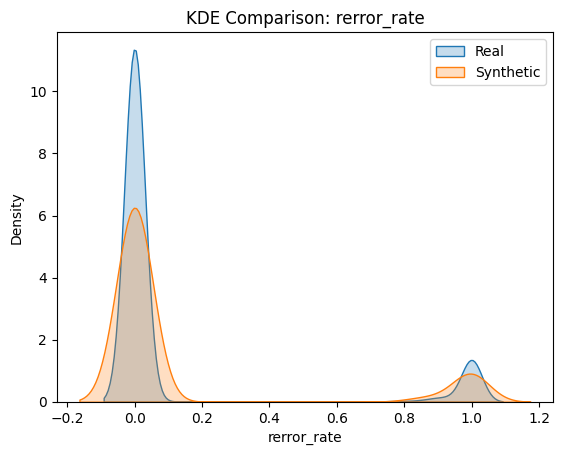

<Figure size 640x480 with 0 Axes>

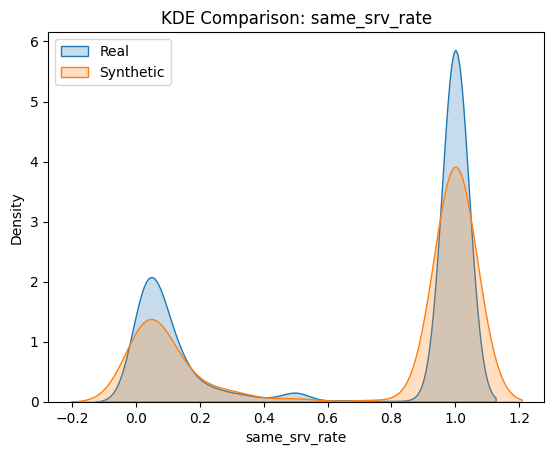

<Figure size 640x480 with 0 Axes>

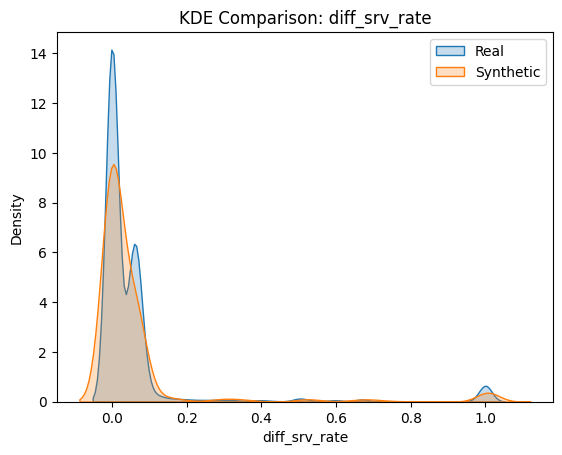

<Figure size 640x480 with 0 Axes>

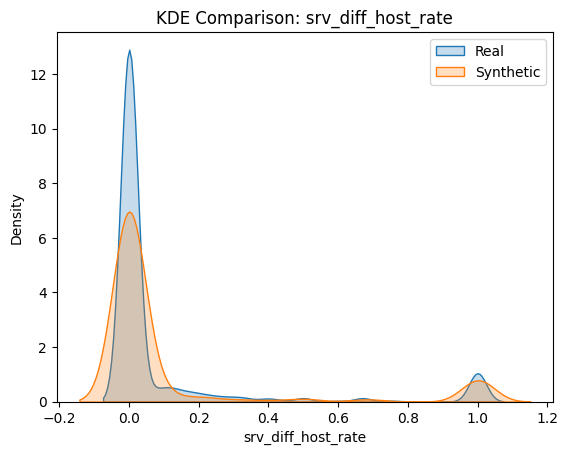

<Figure size 640x480 with 0 Axes>

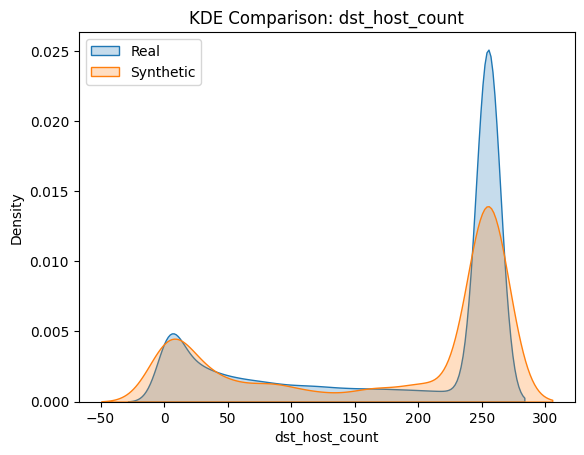

<Figure size 640x480 with 0 Axes>

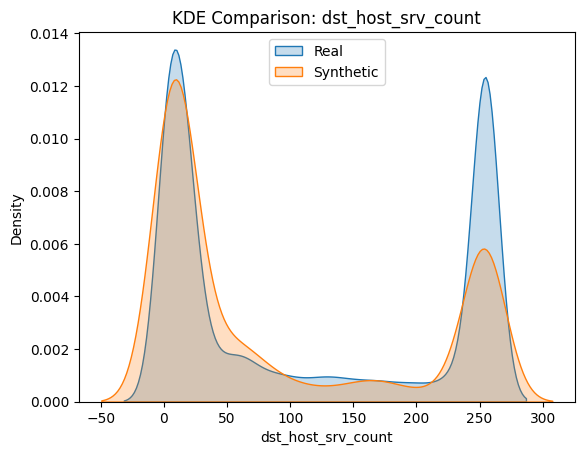

<Figure size 640x480 with 0 Axes>

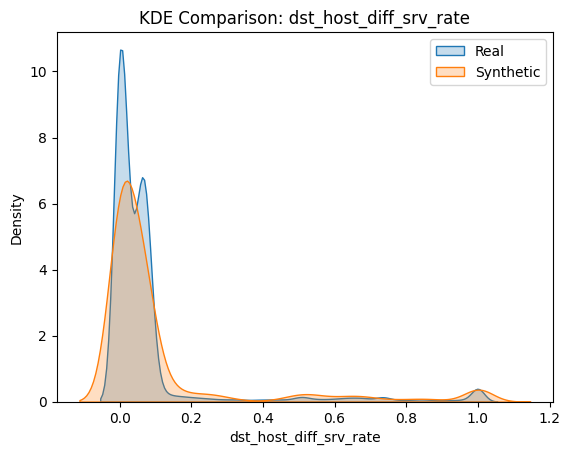

<Figure size 640x480 with 0 Axes>

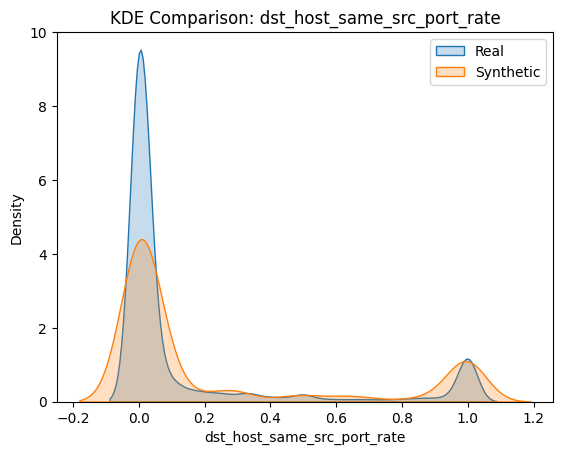

<Figure size 640x480 with 0 Axes>

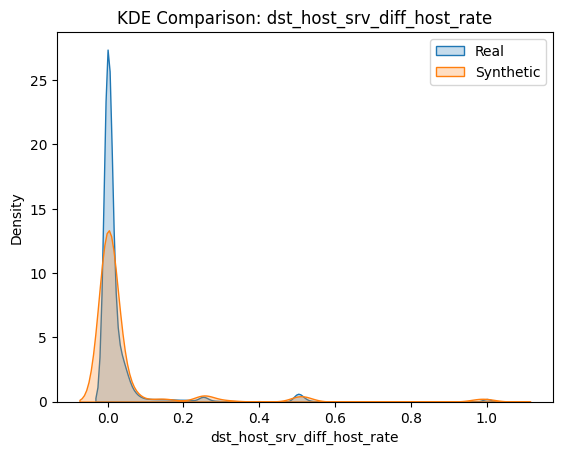

Categorical comparison...


<Figure size 640x480 with 0 Axes>

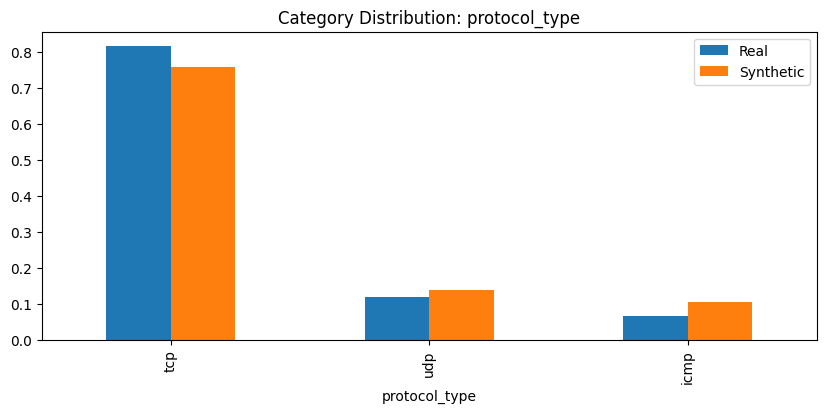

<Figure size 640x480 with 0 Axes>

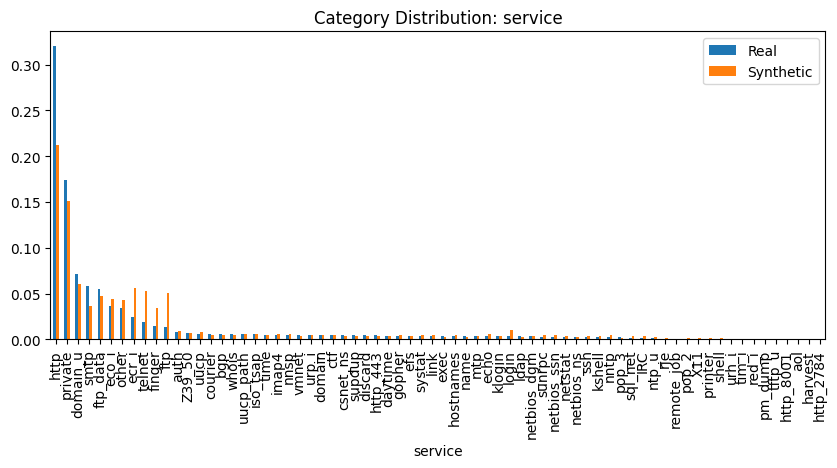

<Figure size 640x480 with 0 Axes>

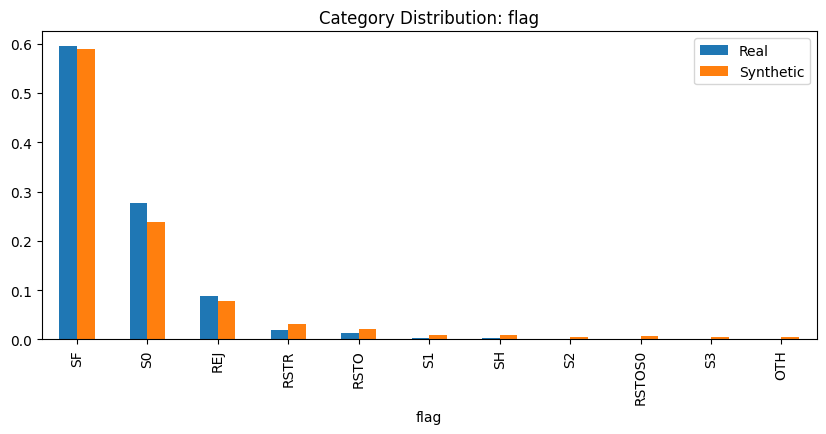

Correlation comparison...


<Figure size 640x480 with 0 Axes>

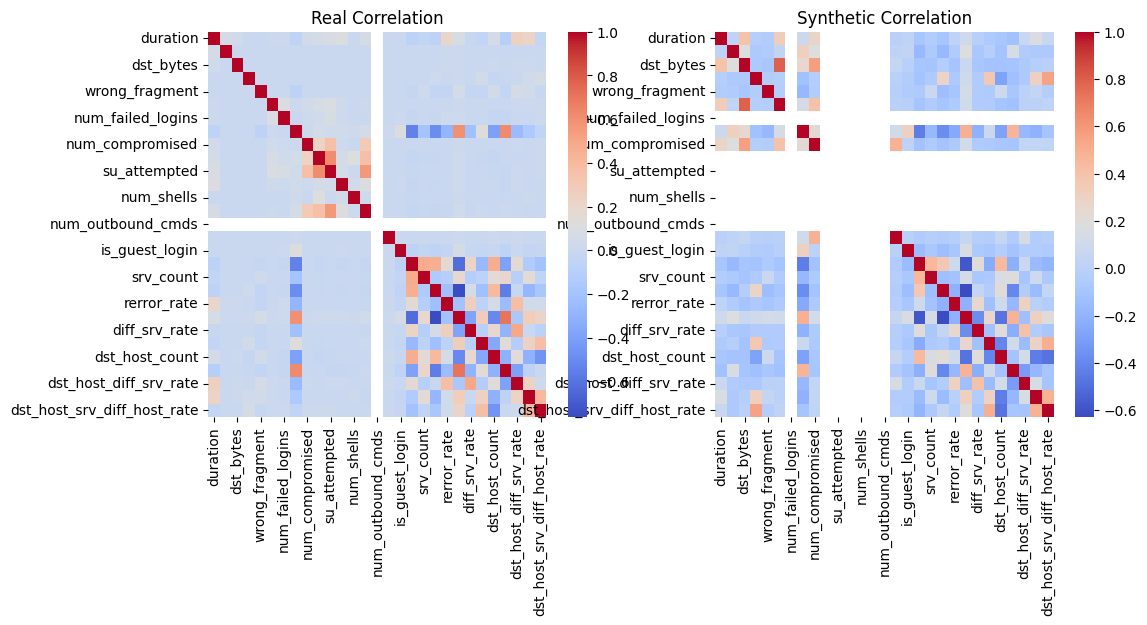

ML utility test...


KeyError: "['class'] not found in axis"

<Figure size 640x480 with 0 Axes>

In [47]:
# do_inputs()

#RUN TEST
print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

# print("Running KS test...")
# ks_results = ks_test(real_df, syn_df, numeric_cols)
# print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)



```
Running KS test...
                         column   ks_stat        p_value
0                      duration  0.487575   0.000000e+00
1                     src_bytes  0.288740   0.000000e+00
2                     dst_bytes  0.210915   0.000000e+00
3                          land  0.028402   6.314188e-07
4                wrong_fragment  0.054947   9.382685e-25
5                        urgent  0.027729   1.272344e-06
6             num_failed_logins  0.000968   1.000000e+00
7                     logged_in  0.048336   2.993259e-19
8               num_compromised  0.027291   1.987579e-06
9                    root_shell  0.001342   1.000000e+00
10                 su_attempted  0.000635   1.000000e+00
11           num_file_creations  0.002278   1.000000e+00
12                   num_shells  0.000373   1.000000e+00
13             num_access_files  0.002945   9.999977e-01
14            num_outbound_cmds  0.000000   1.000000e+00
15                is_host_login  0.006092   8.796233e-01
16               is_guest_login  0.043277   1.622651e-15
17                        count  0.104451   1.825666e-88
18                    srv_count  0.101514   1.419205e-83
19                  serror_rate  0.348967   0.000000e+00
20                  rerror_rate  0.526980   0.000000e+00
21                same_srv_rate  0.346500   0.000000e+00
22                diff_srv_rate  0.351326   0.000000e+00
23           srv_diff_host_rate  0.527063   0.000000e+00
24               dst_host_count  0.056127   8.247780e-26
25           dst_host_srv_count  0.150020  1.692029e-182
26       dst_host_diff_srv_rate  0.162409  5.399232e-214
27  dst_host_same_src_port_rate  0.179390  2.495207e-261
28  dst_host_srv_diff_host_rate  0.218362   0.000000e+00
Categorical comparison...
```



```
ML utility test...
0.9677391187000389
```





In [ ]:
df[["land", "wrong_fragment", "urgent", "hot"]].mean()

,0
land,0.000198
wrong_fragment,0.022687
urgent,0.000111
hot,0.204409


#Repeat For TVAE

In [76]:
from ctgan import TVAE

tvae = TVAE(cuda=True)

/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [77]:
discrete_columns = [
    "protocol_type", "service", "flag",
    "land", "wrong_fragment", "urgent",
    "logged_in", "is_host_login", "is_guest_login",
    "class"
]

In [78]:
tvae = TVAE(cuda=True)

start_time = time.time()
print(f"Fitting TVAE Model [{start_time}]...")
tvae.fit(df, discrete_columns=discrete_columns)
end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {start_time - end_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = tvae.sample(1000)
end_time = time.time()
samples.to_csv(base_path+"/tvae_network_samples.csv", index=False)


print(f"1000 Samples in {start_time - end_time}.")

start_time = time.time()
print(f"Starting large batch of samples [{start_time}].")

for i in range(10):
  samples = tvae.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/tvae_network_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/tvae_network_samples_large.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"10000 Samples in {end_time - start_time}. Finished [{end_time}].")

for i in range(100):
  samples = tvae.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/tvae_network_samples_XLlarge.csv", index=False)
  else:
    samples.to_csv(base_path+"/tvae_network_samples_XLlarge.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"100000 Samples in {end_time - start_time}. Finished [{end_time}].")


/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


Fitting TVAE Model [1776804010.969047]...
Finished fitting [1776806857.892038]. Total run time: -2846.922991037369.
Generating Samples [1776806857.892304]...
1000 Samples in -0.12148451805114746.
Starting large batch of samples [1776806858.0485878].
10000 Samples in 1.5305871963500977. Finished [1776806859.579175].
100000 Samples in 18.69219446182251. Finished [1776806876.7407823].


In [24]:
import pandas as pd
import os

synthetic_df = pd.read_csv(base_path+"/tvae_network_samples_large.csv")

os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [25]:
do_inputs()
syn_df[numeric_cols] = syn_df[numeric_cols].clip(lower=0)

Running KDE plots...


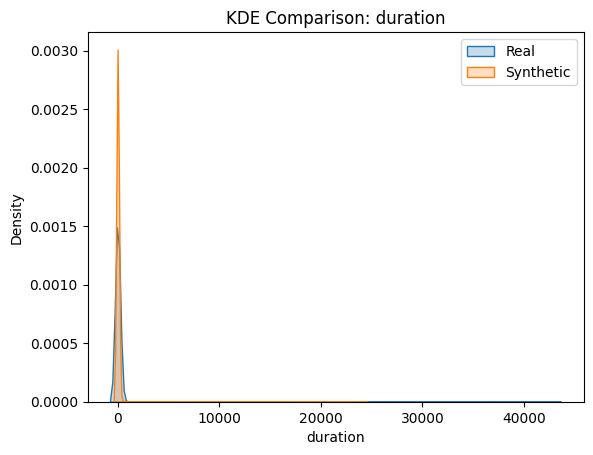

<Figure size 640x480 with 0 Axes>

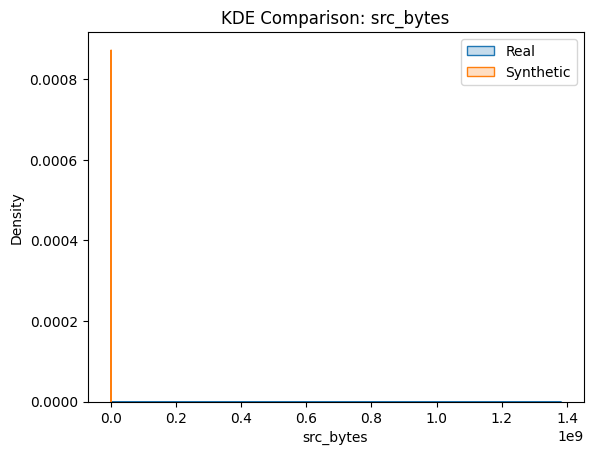

<Figure size 640x480 with 0 Axes>

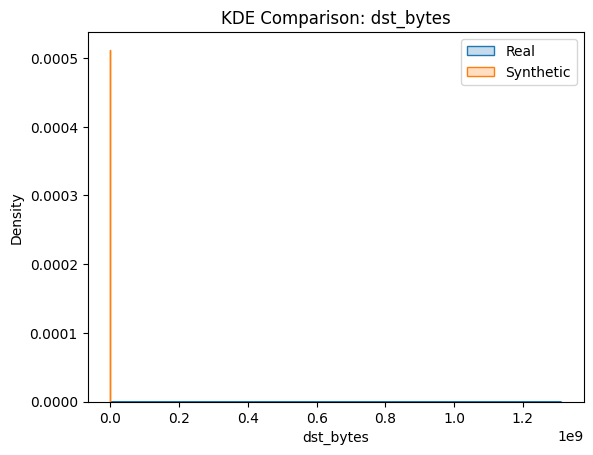

<Figure size 640x480 with 0 Axes>

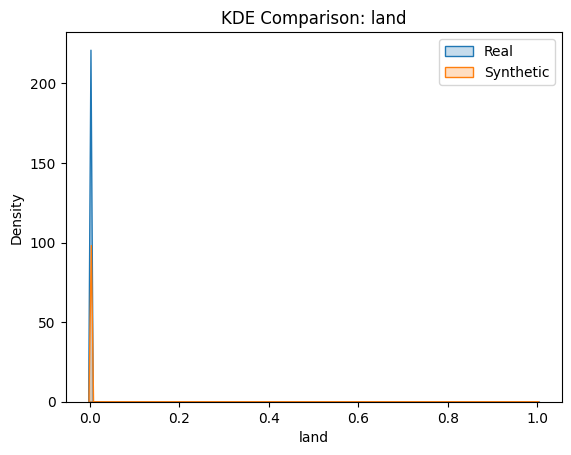

<Figure size 640x480 with 0 Axes>

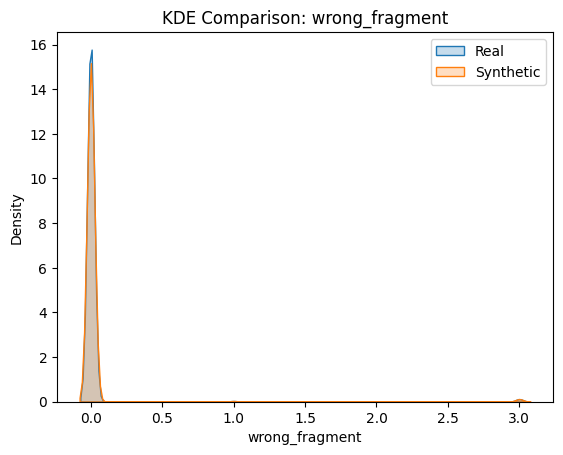

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

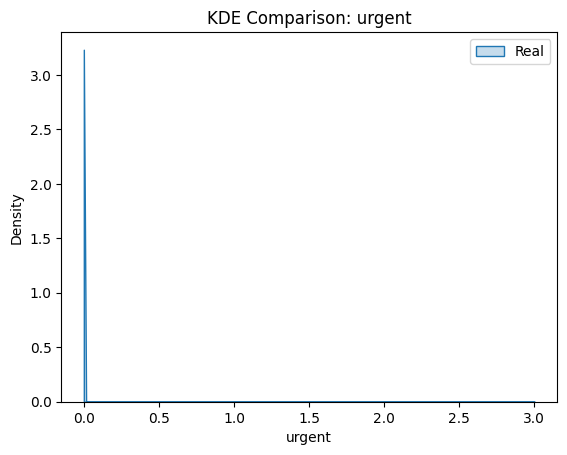

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

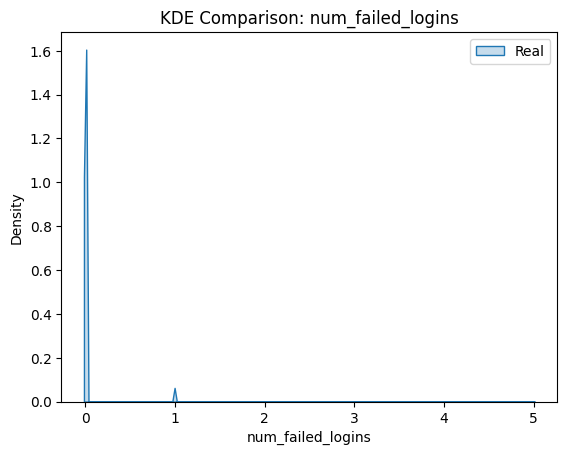

<Figure size 640x480 with 0 Axes>

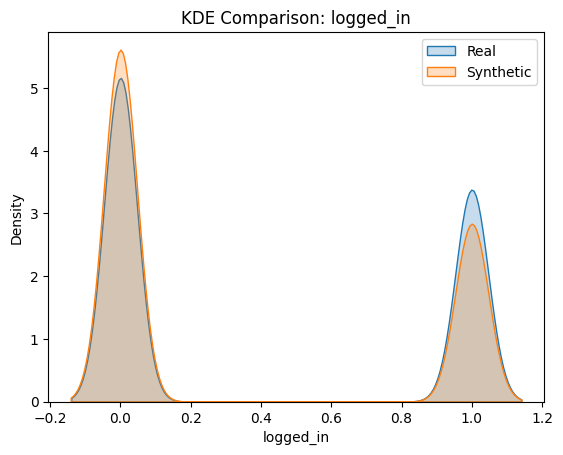

<Figure size 640x480 with 0 Axes>

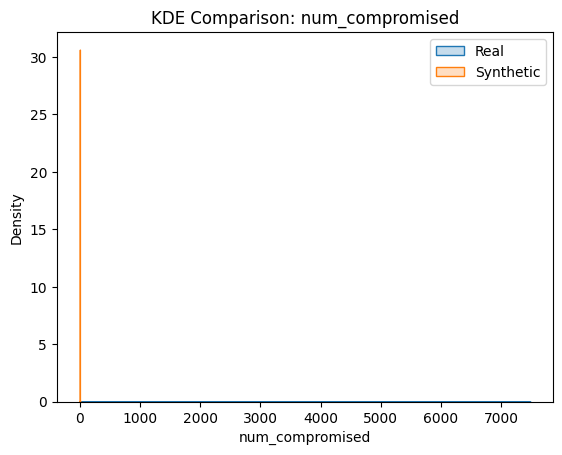

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

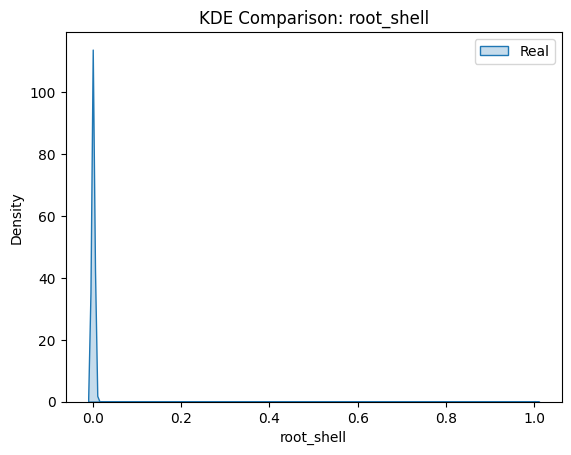

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

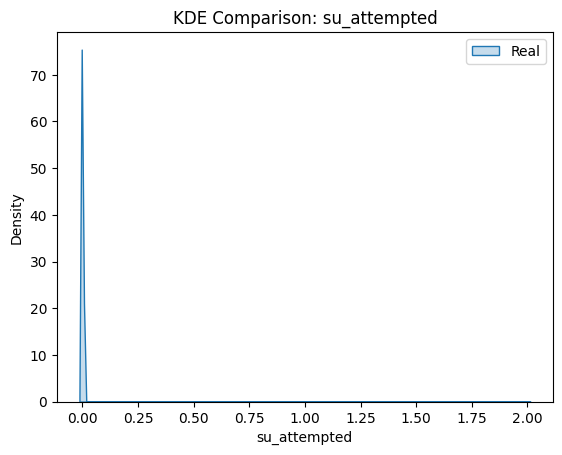

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

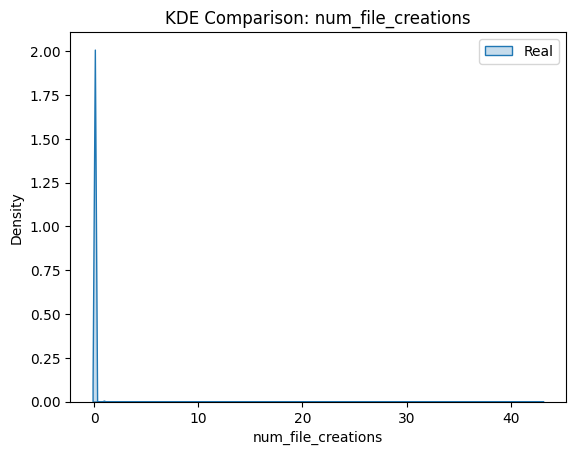

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

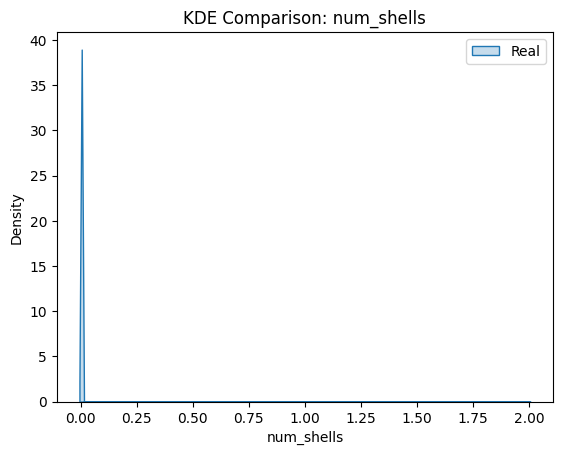

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

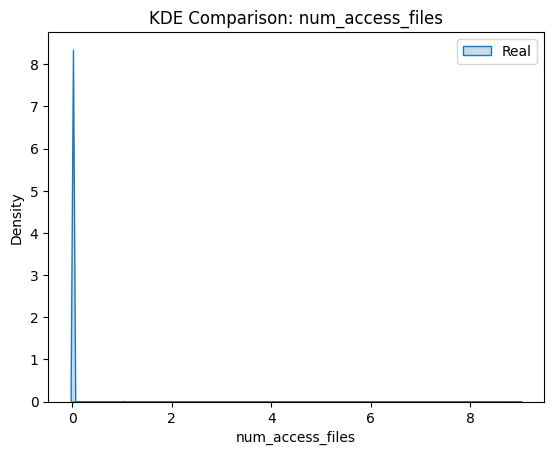

/tmp/ipykernel_10033/1199787676.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(real[col], label="Real", fill=True)
/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)
/tmp/ipykernel_10033/1199787676.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

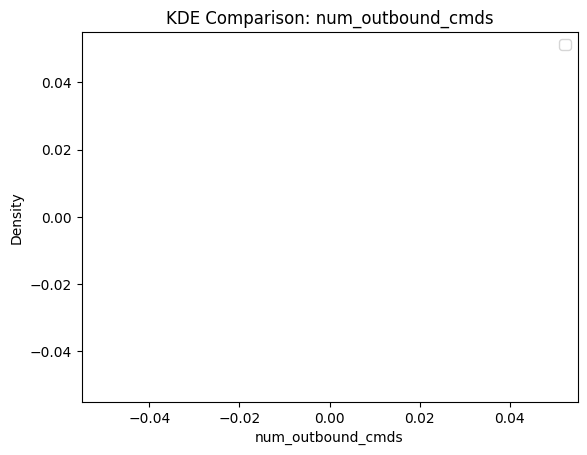

/tmp/ipykernel_10033/1199787676.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(syn[col], label="Synthetic", fill=True)


<Figure size 640x480 with 0 Axes>

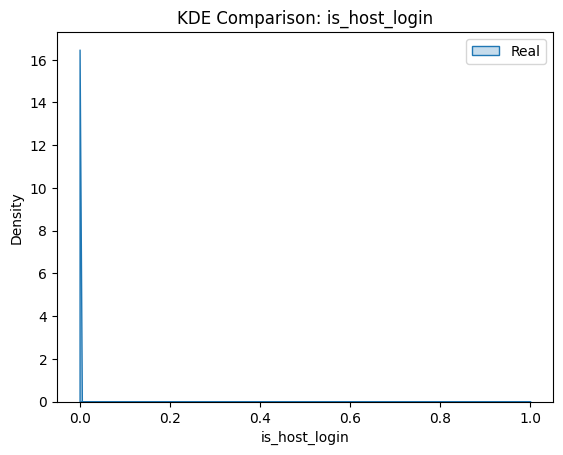

<Figure size 640x480 with 0 Axes>

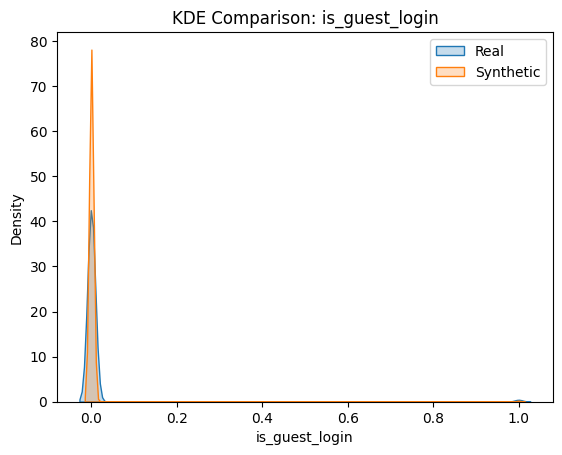

<Figure size 640x480 with 0 Axes>

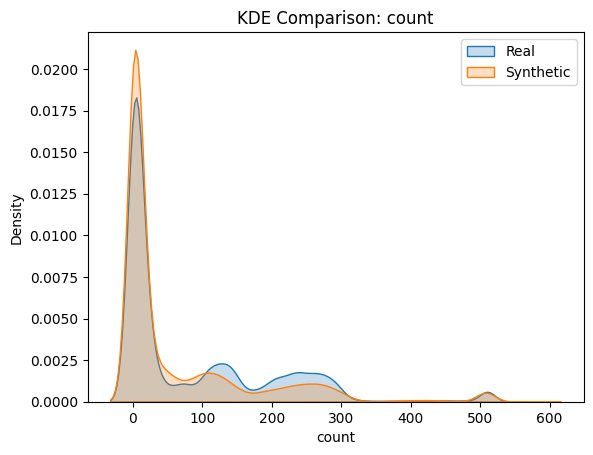

<Figure size 640x480 with 0 Axes>

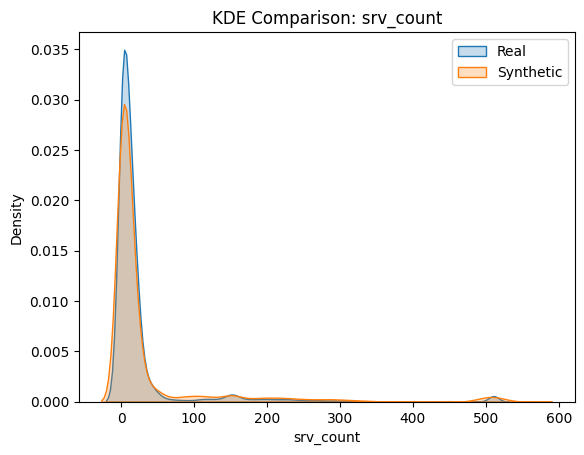

<Figure size 640x480 with 0 Axes>

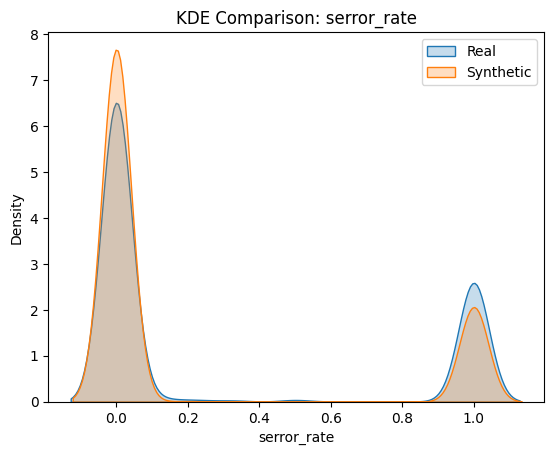

<Figure size 640x480 with 0 Axes>

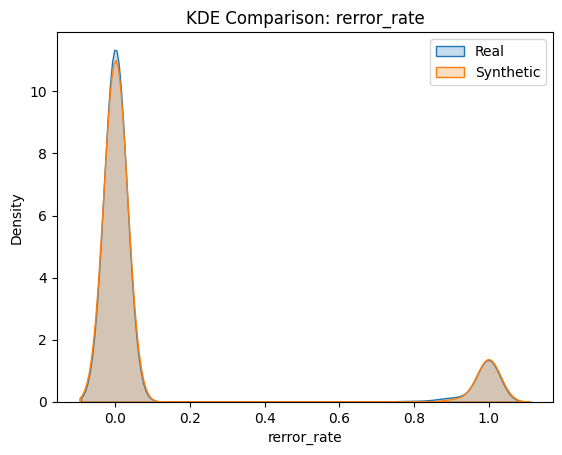

<Figure size 640x480 with 0 Axes>

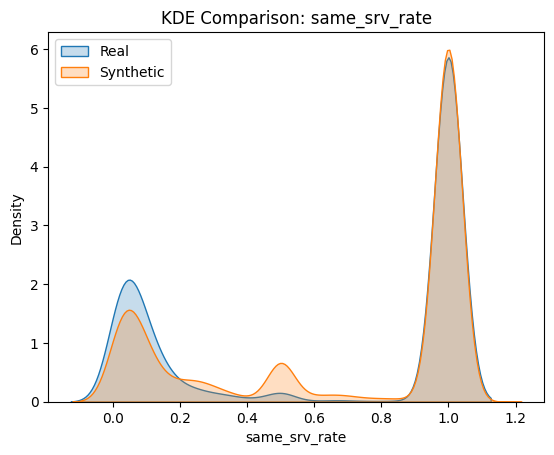

<Figure size 640x480 with 0 Axes>

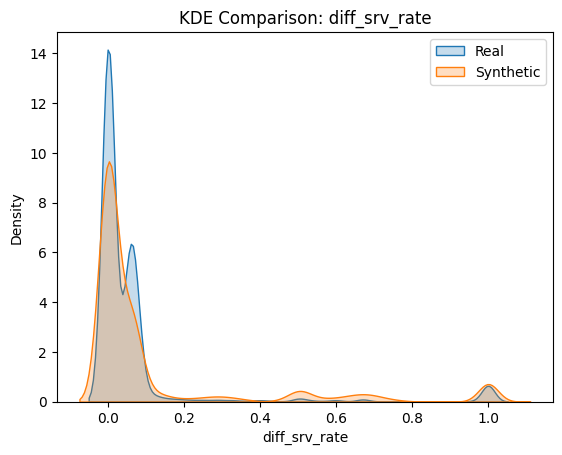

<Figure size 640x480 with 0 Axes>

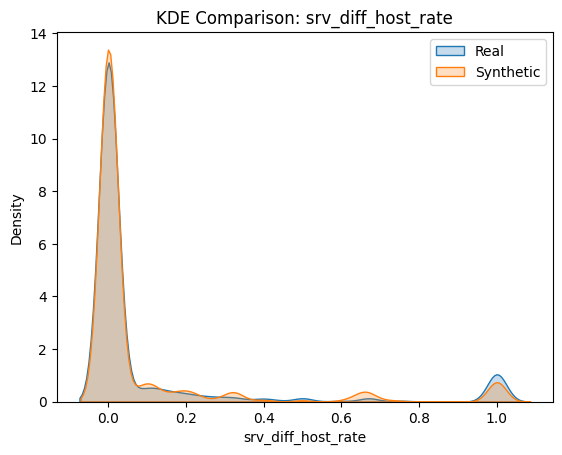

<Figure size 640x480 with 0 Axes>

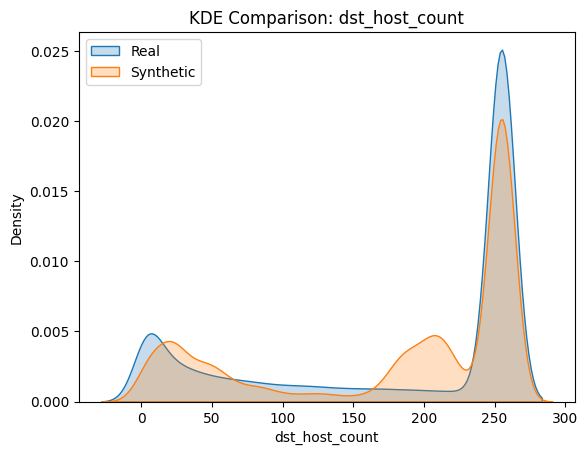

<Figure size 640x480 with 0 Axes>

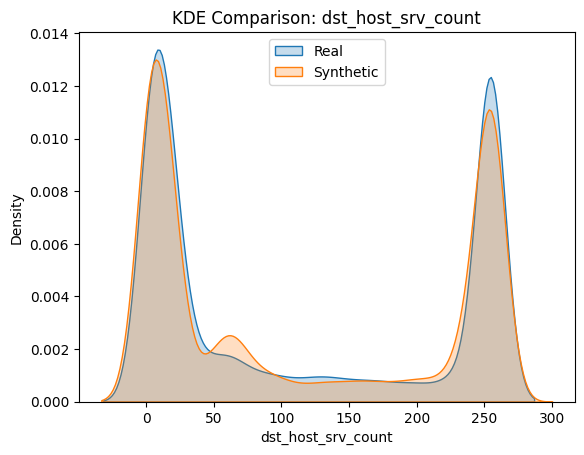

<Figure size 640x480 with 0 Axes>

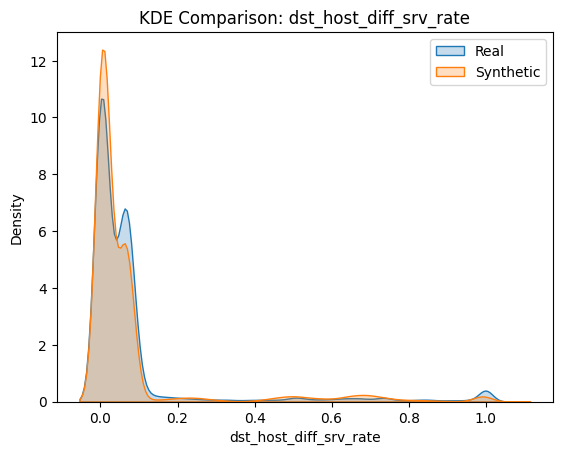

<Figure size 640x480 with 0 Axes>

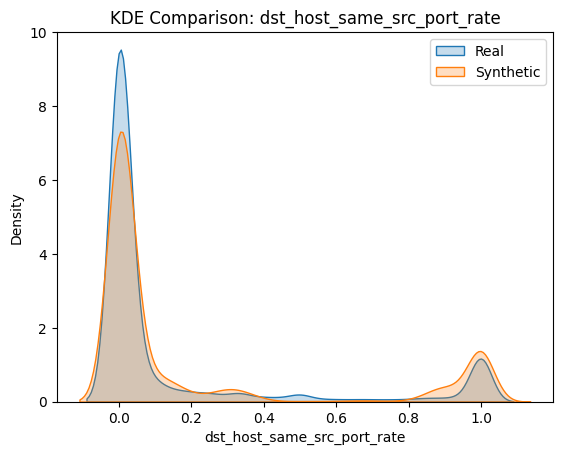

<Figure size 640x480 with 0 Axes>

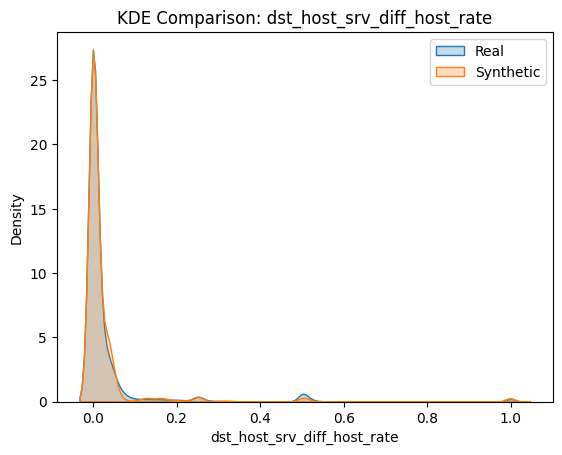

<Figure size 640x480 with 0 Axes>

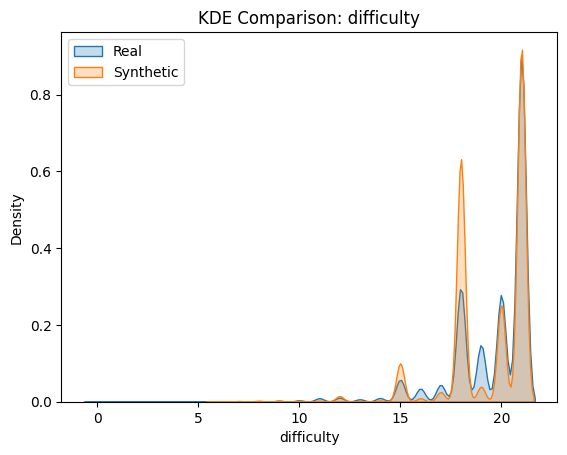

                         column   ks_stat        p_value
0                      duration  0.120945   0.000000e+00
1                     src_bytes  0.267465   0.000000e+00
2                     dst_bytes  0.287948   0.000000e+00
3                          land  0.000078   1.000000e+00
4                wrong_fragment  0.000437   1.000000e+00
5                        urgent  0.000071   1.000000e+00
6             num_failed_logins  0.000968   1.000000e+00
7                     logged_in  0.060026  4.777441e-175
8               num_compromised  0.007199   6.162977e-03
9                    root_shell  0.001342   9.999619e-01
10                 su_attempted  0.000635   1.000000e+00
11           num_file_creations  0.002278   9.337827e-01
12                   num_shells  0.000373   1.000000e+00
13             num_access_files  0.002945   7.177833e-01
14            num_outbound_cmds  0.000000   1.000000e+00
15                is_host_login  0.000008   1.000000e+00
16               is_guest_login

<Figure size 640x480 with 0 Axes>

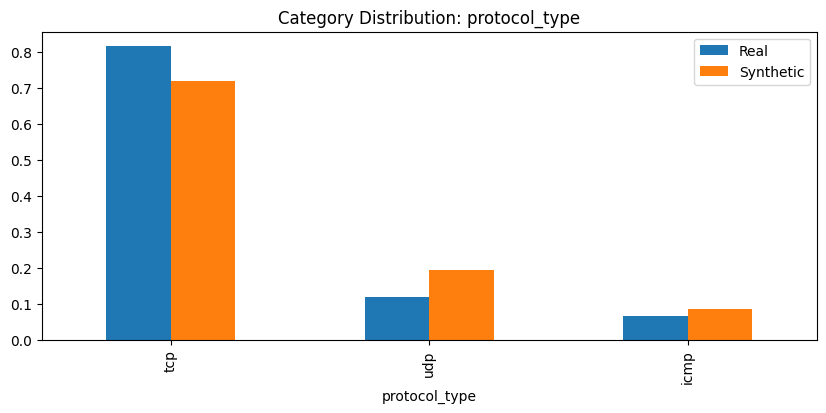

<Figure size 640x480 with 0 Axes>

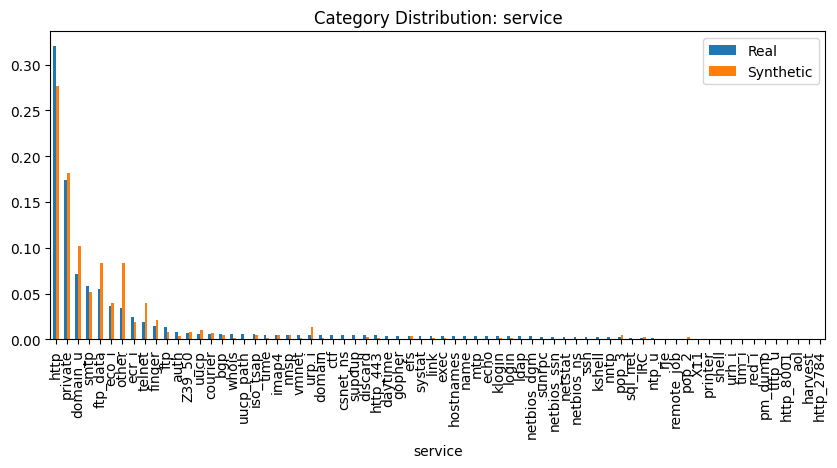

<Figure size 640x480 with 0 Axes>

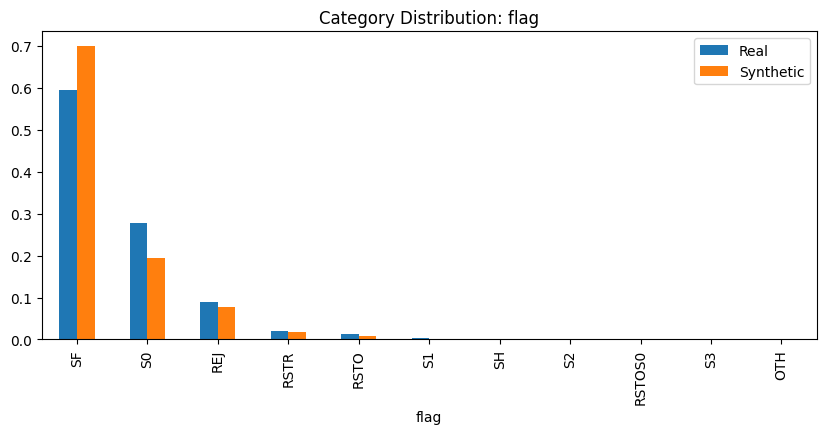

Correlation comparison...


<Figure size 640x480 with 0 Axes>

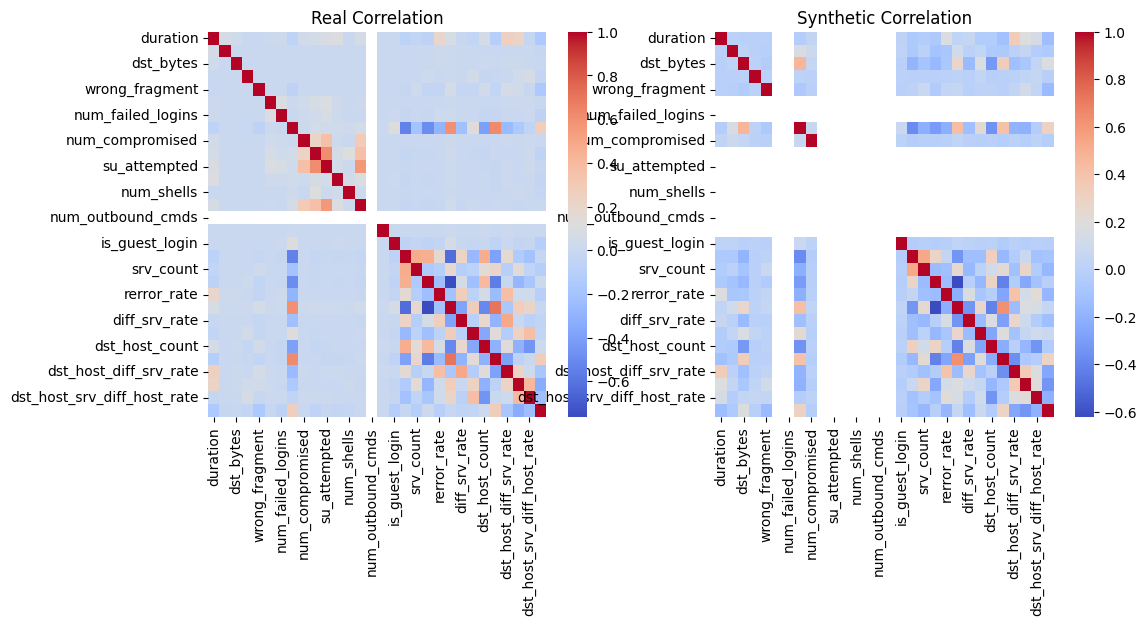

ML utility test...
0.9598167861367118


<Figure size 640x480 with 0 Axes>

In [26]:
do_inputs()

#RUN TEST
print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

# print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)




```
0                      duration  0.120945   0.000000e+00
1                     src_bytes  0.267465   0.000000e+00
2                     dst_bytes  0.287948   0.000000e+00
3                          land  0.000078   1.000000e+00
4                wrong_fragment  0.000437   1.000000e+00
5                        urgent  0.000071   1.000000e+00
6             num_failed_logins  0.000968   1.000000e+00
7                     logged_in  0.060026  4.777441e-175
8               num_compromised  0.007199   6.162977e-03
9                    root_shell  0.001342   9.999619e-01
10                 su_attempted  0.000635   1.000000e+00
11           num_file_creations  0.002278   9.337827e-01
12                   num_shells  0.000373   1.000000e+00
13             num_access_files  0.002945   7.177833e-01
14            num_outbound_cmds  0.000000   1.000000e+00
15                is_host_login  0.000008   1.000000e+00
16               is_guest_login  0.006833   1.092658e-02
17                        count  0.111939   0.000000e+00
18                    srv_count  0.099344   0.000000e+00
19                  serror_rate  0.341857   0.000000e+00
20                  rerror_rate  0.499430   0.000000e+00
21                same_srv_rate  0.331750   0.000000e+00
22                diff_srv_rate  0.312326   0.000000e+00
23           srv_diff_host_rate  0.387203   0.000000e+00
24               dst_host_count  0.128380   0.000000e+00
25           dst_host_srv_count  0.084350   0.000000e+00
26       dst_host_diff_srv_rate  0.205159   0.000000e+00
27  dst_host_same_src_port_rate  0.298460   0.000000e+00
28  dst_host_srv_diff_host_rate  0.345762   0.000000e+00
29                   difficulty  0.127404   0.000000e+00
Categorical comparison...
<Figure size 640x480 with 0 Axes>
```


```
ML utility test...
0.9598167861367118
<Figure size 640x480 with 0 Axes>
```

